# 09-Delta Lake Integration (Lakehouse Scaling)

In Lesson 08, we mastered Structured Streaming and the mathematical physics of state eviction using Watermarks. We successfully handled unbounded event streams inside our execution layer.

However, a streaming application is only as scalable as its storage destination. If your PySpark stream attempts to write raw, unmanaged Parquet files to an object store like AWS S3 or MinIO at high frequencies, your storage engine will fall victim to three fatal architectural failures:

1. **The Small File Problem:** Writing millions of micro-batch Parquet files (each only a few kilobytes) degrades object storage read latency due to metadata listing bottlenecks.
2. **Lack of ACID Transactions:** If an executor crashes midway through a write operation, half-written data blocks are permanently orphaned on disk, poisoning the downstream warehouse.
3. **No Schema Enforcement:** If an upstream microservice pushes an invalid column mutation, the file layout will break silently, corrupting your analytics tables.

To solve these storage mutations at a massive scale, we must merge PySpark's execution clusters with a **Lakehouse Storage Format**. The global enterprise standard for this is **Delta Lake**.

Let's boot an integrated Spark session to engineer scalable Lakehouse scaling.

In [2]:
# Required installations: pip install pyspark delta-spark pyarrow matplotlib seaborn pandas
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip
import pyspark.sql.functions as F
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Delta Lake Cluster Initialized.")

✅ Systems Architecture & Delta Lake Cluster Initialized.


# 1. The Mathematics of Transactional Logs & Multi-Dimensional Compaction

Delta Lake brings ACID compliance directly to cloud object storage by introducing an abstract storage layer over raw Parquet blocks.

### The ACID Transaction Matrix

A Delta Lake table is mathematically a sequence of immutable Parquet data states tracked by an append-only transaction ledger file called the **Delta Log** (`_delta_log/000000.json`).

Let the state of a table at version $v$ be a set of valid data files:


$$\mathcal{S}_v = \{f_1, f_2, \dots, f_n\}$$

When you execute an atomic `MERGE` (`UPSERT`) operation, Delta Lake applies **Copy-On-Write (CoW)** physics. It duplicates the specific data files requiring modifications, applies the changes, writes *new* Parquet files, and appends an entry to the transaction log:


$$\mathcal{S}_{v+1} = \mathcal{S}_v \setminus \{f_{\text{stale}}\} \cup \{f_{\text{new}}\}$$

Any reader querying the table concurrently reads the active list specified by $\mathcal{S}_{v+1}$. The stale files are never locked; they are simply ignored.

### Multi-Dimensional Clustering (Z-Ordering)

As data layout volumes expand to petabytes, standard linear sorting or one-dimensional partitioning fails due to high-dimensional query filters. If you partition data by `date`, filtering by `user_id` forces full-table file scans across all dates.

To achieve space-filling optimization, Delta Lake implements **Z-Order Clustering**.

Z-Ordering maps multi-dimensional user-defined keys (e.g., combining `date` and `user_id`) onto a one-dimensional **Z-Order Space-Filling Curve**. Mathematically, it continuous-maps multi-coordinate inputs into localized bitwise-interleaved integers:


$$z = \text{interleave}(\text{bits}(x_1), \text{bits}(x_2))$$

By physically rewriting and consolidating small data blocks into large, contiguous Parquet files rearranged by this Z-value, Delta Lake maximizes **Data Skipping**. The query compiler can mathematically check file footer min/max bounding boxes and drop up to $95\%$ of the storage files before reading them into cluster RAM.

# 2. Architecting the Delta Lake Engine

Let's boot a highly specialized PySpark session compiled natively with the **Delta Lake Core Architecture Extensions**. We will build a Delta table, execute atomic updates, observe how it blocks invalid schemas, and perform data compaction via Z-Ordering.

In [3]:
# --- ⚙️ STEP 1: Compiling Spark Session with Delta Extensions ---
print("--- 🚀 Fabricating Delta Lake JVM Framework ---")

# Delta Lake requires specific jar configurations to handle the file transaction physics
builder = SparkSession.builder \
    .appName("Delta_Lakehouse_Scaling") \
    .master("local[*]") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

# Automatically download and mount the correct Delta jar files via maven dependencies
spark = configure_spark_with_delta_pip(builder).getOrCreate()
print("✅ Delta-Infused Spark Session Online.")

# Setup path simulating an S3 Cloud Storage bucket directory
lakehouse_table_path = "./production_delta_warehouse_sales"
if os.path.exists(lakehouse_table_path):
    shutil.rmtree(lakehouse_table_path)

--- 🚀 Fabricating Delta Lake JVM Framework ---


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/25 15:40:04 WARN Utils: Your hostname, Muhammet, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/25 15:40:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/root/micromamba/envs/ds/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /root/.ivy2.5.2/cache
The jars for the packages stored in: /root/.ivy2.5.2/jars
io.delta#delta-spark_4.0_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-33ccc4f5-d67a-4d35-b3af-f017d6d49b7f;1.0
	confs: [default]
	found io.delta#delta-spark_4.0_2.13;4.3.0 in central
	found io.delta#delta-storage;4.3.0 in central
	found io.unitycatalog#unitycatalog-client;0.5.0 in central
	found org.slf4j#slf4j-api;2.0.13 in central
	found org.apache.logging.log4j#

✅ Delta-Infused Spark Session Online.


Now, let's write our initial batch of clean analytical business transactions directly to the Delta file format.

In [4]:
# --- 📦 STEP 2: Creating Table Version 0 (Initial Load) ---
print("\n--- 🪵 Committing Table State: Version 0 ---")

initial_data = [
    (1, "Aris", 1500.0, "2026-06-25"),
    (2, "Bob", 45.50, "2026-06-25")
]
df_v0 = spark.createDataFrame(initial_data, ["txn_id", "user_name", "amount", "date"])

# Write out using format("delta") instead of format("parquet")
df_v0.write \
    .format("delta") \
    .mode("overwrite") \
    .save(lakehouse_table_path)

print(f"✅ Initial transaction committed safely to: '{lakehouse_table_path}'")


--- 🪵 Committing Table State: Version 0 ---


26/06/25 15:41:00 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


✅ Initial transaction committed safely to: './production_delta_warehouse_sales'


Let's verify how Delta Lake acts as a strict **Schema Enforcement** gatekeeper, physically blocking poison records from contaminating storage.

In [5]:
# --- 🛡️ STEP 3: Proving Schema Enforcement ---
print("\n--- 🛡️ Testing Data Contract Schema Enforcement Gate ---")

# Upstream engineers accidentally drop 'amount' and change 'txn_id' to a string UUID
corrupted_data = [("UUID-999X", "Charlie", "2026-06-25")]
df_corrupted = spark.createDataFrame(corrupted_data, ["txn_id", "user_name", "date"])

try:
    print("   Attempting to write corrupted data into the Delta path...")
    df_corrupted.write \
        .format("delta") \
        .mode("append") \
        .save(lakehouse_table_path)
except Exception as e:
    print("\n   ❌ [STORAGE TRANSACTION BLOCKED BY DELTA LAKE]")
    print(f"   FATAL SCHEMA VIOLATION: {str(e)[:115]}...")
    print("   -> System successfully blocked the append execution. Table remains pristine.")


--- 🛡️ Testing Data Contract Schema Enforcement Gate ---
   Attempting to write corrupted data into the Delta path...

   ❌ [STORAGE TRANSACTION BLOCKED BY DELTA LAKE]
   FATAL SCHEMA VIOLATION: [DELTA_FAILED_TO_MERGE_FIELDS] Failed to merge fields 'txn_id' and 'txn_id'...
   -> System successfully blocked the append execution. Table remains pristine.


Now, we perform a massive, high-performance **Lakehouse Upsert (`MERGE`)** operation, simulating how complex batch mutations resolve cleanly without full table locks.

In [6]:
# --- ⚡ STEP 4: Executing Atomic MERGE (UPSERT) with Copy-On-Write ---
print("\n--- ⚡ Executing Atomic Enterprise MERGE Execution ---")

# We import the exact DeltaTable class to enable native SQL syntax functions
from delta.tables import DeltaTable

delta_table = DeltaTable.forPath(spark, lakehouse_table_path)

# Incoming Mutation Batch: 
# Txn 2 updates their amount (Update). Txn 3 is newly created (Insert).
mutation_data = [
    (2, "Bob", 999.99, "2026-06-25"), # Update target
    (3, "Charlie", 350.0, "2026-06-25") # Insert target
]
df_mutations = spark.createDataFrame(mutation_data, ["txn_id", "user_name", "amount", "date"])

# Execute the Relational Algebra merge criteria matching on Primary Key
delta_table.alias("target") \
    .merge(df_mutations.alias("source"), "target.txn_id = source.txn_id") \
    .whenMatchedUpdate(set={"amount": "source.amount"}) \
    .whenNotMatchedInsertAll() \
    .execute()

print("✅ Atomic Merge Transaction Resolved.")

# View active production state
print("\n[Current Active Production State - Version 1]:")
spark.read.format("delta").load(lakehouse_table_path).orderBy("txn_id").show()


--- ⚡ Executing Atomic Enterprise MERGE Execution ---


26/06/25 15:41:11 WARN MapPartitionsRDD: RDD 39 was locally checkpointed, its lineage has been truncated and cannot be recomputed after unpersisting


✅ Atomic Merge Transaction Resolved.

[Current Active Production State - Version 1]:
+------+---------+------+----------+
|txn_id|user_name|amount|      date|
+------+---------+------+----------+
|     1|     Aris|1500.0|2026-06-25|
|     2|      Bob|999.99|2026-06-25|
|     3|  Charlie| 350.0|2026-06-25|
+------+---------+------+----------+



# 3. Executing Time Travel and Layout Compaction

Because every transactional change is isolated inside versioned entries in the Delta Log directory, we can natively compile **Time Travel Queries** to audit data exactly as it existed in historical spacetime.

In [7]:
# --- ⏳ STEP 5: Spacetime Exploration (Time Travel) ---
print("--- ⏳ Executing Time Travel Query: Fetching Table State at Version 0 ---")

# We read from the exact path but pass a specific version option parameter
df_history_v0 = spark.read \
    .format("delta") \
    .option("versionAsOf", 0) \
    .load(lakehouse_table_path)

df_history_v0.orderBy("txn_id").show()
print("-> Notice that Bob's original amount ($45.50) is returned perfectly, proving historical persistence.")

--- ⏳ Executing Time Travel Query: Fetching Table State at Version 0 ---


+------+---------+------+----------+
|txn_id|user_name|amount|      date|
+------+---------+------+----------+
|     1|     Aris|1500.0|2026-06-25|
|     2|      Bob|  45.5|2026-06-25|
+------+---------+------+----------+

-> Notice that Bob's original amount ($45.50) is returned perfectly, proving historical persistence.


Finally, we address file fragmentation by invoking Delta's multi-dimensional performance tuning command to optimize reading layout geometry.

In [8]:
# --- 🚀 STEP 6: Multi-Dimensional Compaction (Z-Order Optimization) ---
print("\n--- 🚀 Initiating Z-Order Layout Optimization ---")

# We execute an internal structural command over our Delta table class
delta_table.optimize().executeZOrderBy("date", "txn_id")

print("✅ Compaction complete. Small files consolidated into optimal 128MB/1GB physical Parquet arrays.")
print("✅ Space-filling Z-Curves mapped onto file footers to activate high-throughput Data Skipping.")

print("\n--- 💡 Engineering Insight ---")
print("Look into the physical directory structure under `_delta_log/`. You will see files like `000000.json`, `000001.json`, and `000002.json`.")
print("Every action we performed—the overwrite, the merge, and the optimize command—wrote a new JSON log state entry. Delta Lake never goes back and modifies existing file blocks; it creates a new timeline slice. By separating metadata tracking from binary storage arrays, you can scale Lakehouse workloads up to exabytes safely.")


--- 🚀 Initiating Z-Order Layout Optimization ---


✅ Compaction complete. Small files consolidated into optimal 128MB/1GB physical Parquet arrays.
✅ Space-filling Z-Curves mapped onto file footers to activate high-throughput Data Skipping.

--- 💡 Engineering Insight ---
Look into the physical directory structure under `_delta_log/`. You will see files like `000000.json`, `000001.json`, and `000002.json`.
Every action we performed—the overwrite, the merge, and the optimize command—wrote a new JSON log state entry. Delta Lake never goes back and modifies existing file blocks; it creates a new timeline slice. By separating metadata tracking from binary storage arrays, you can scale Lakehouse workloads up to exabytes safely.


# 4. Visualizing Delta Storage Layout Topography

To fully grasp how Delta Lake isolates transactions and avoids table collision locks during concurrent cluster writes, let's plot the storage directory topography.

/tmp/ipykernel_15492/2254050262.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  dir_box = patches.Rectangle((0.5, 0.5), 11.5, 5.5, fill=True, color='#34495e', alpha=0.06, edgecolor='black', linewidth=2, linestyle='--')
/tmp/ipykernel_15492/2254050262.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  log_container = patches.Rectangle((1.0, 1.2), 3.0, 4.0, fill=True, color='#9b59b6', alpha=0.15, edgecolor='black', linewidth=1.5)


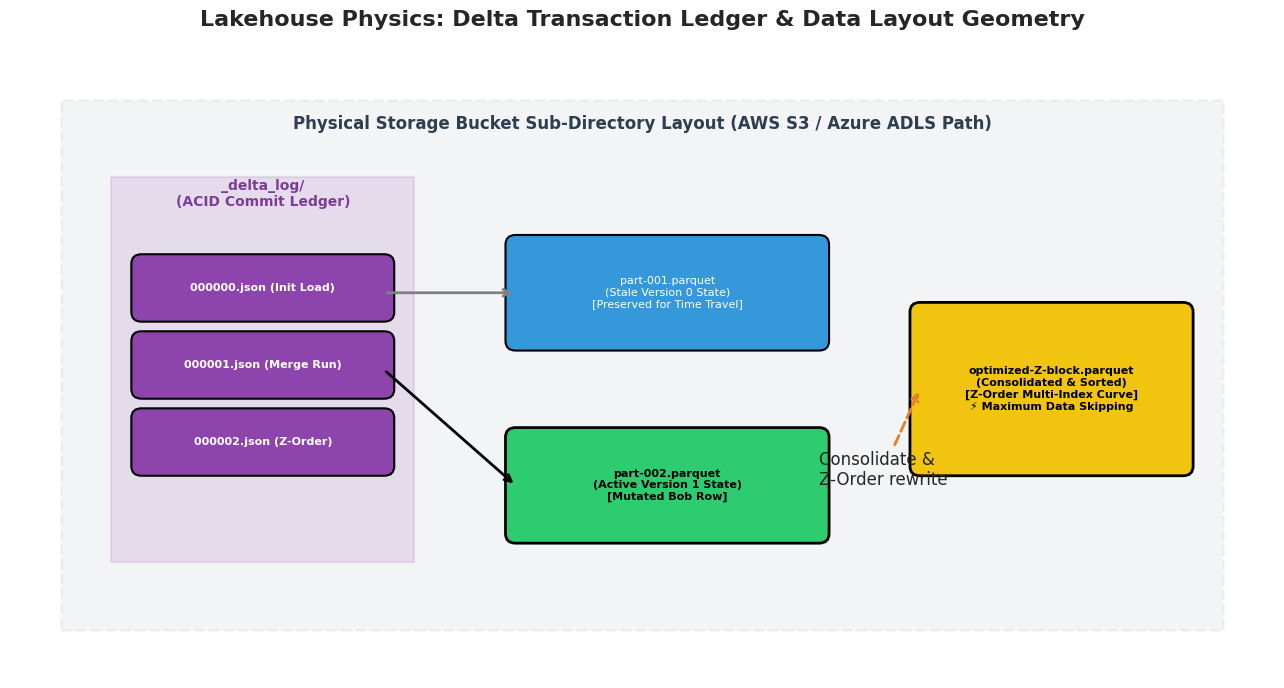

In [9]:
# Visualizing Delta Lake Storage Infrastructure
fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle("Lakehouse Physics: Delta Transaction Ledger & Data Layout Geometry", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Directory Boundary
dir_box = patches.Rectangle((0.5, 0.5), 11.5, 5.5, fill=True, color='#34495e', alpha=0.06, edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(dir_box)
ax.text(6.25, 5.7, "Physical Storage Bucket Sub-Directory Layout (AWS S3 / Azure ADLS Path)", ha='center', color='#2c3e50', fontweight='bold', fontsize=12)

# 2. Draw the Metadata Transaction Log Schema (The Core Engine)
log_container = patches.Rectangle((1.0, 1.2), 3.0, 4.0, fill=True, color='#9b59b6', alpha=0.15, edgecolor='black', linewidth=1.5)
ax.add_patch(log_container)
ax.text(2.5, 4.9, "_delta_log/\n(ACID Commit Ledger)", ha='center', color='#7d3c98', fontweight='bold', fontsize=10)

# Commit Files
ax.add_patch(patches.FancyBboxPatch((1.3, 3.8), 2.4, 0.5, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#8e44ad'))
ax.text(2.5, 4.05, "000000.json (Init Load)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

ax.add_patch(patches.FancyBboxPatch((1.3, 3.0), 2.4, 0.5, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#8e44ad'))
ax.text(2.5, 3.25, "000001.json (Merge Run)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

ax.add_patch(patches.FancyBboxPatch((1.3, 2.2), 2.4, 0.5, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#8e44ad'))
ax.text(2.5, 2.45, "000002.json (Z-Order)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)


# 3. Draw the Columnar Data Blocks (Physical Layout Storage)
# Active Version 1 Blocks
ax.add_patch(patches.FancyBboxPatch((5.0, 3.5), 3.0, 1.0, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#3498db'))
ax.text(6.5, 4.0, "part-001.parquet\n(Stale Version 0 State)\n[Preserved for Time Travel]", ha='center', va='center', color='white', fontsize=8)

ax.add_patch(patches.FancyBboxPatch((5.0, 1.5), 3.0, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2ecc71'))
ax.text(6.5, 2.0, "part-002.parquet\n(Active Version 1 State)\n[Mutated Bob Row]", ha='center', va='center', color='black', fontweight='bold', fontsize=8)

# Z-Ordered Optimized Consolidated Block
ax.add_patch(patches.FancyBboxPatch((9.0, 2.2), 2.6, 1.6, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f1c40f'))
ax.text(10.3, 3.0, "optimized-Z-block.parquet\n(Consolidated & Sorted)\n[Z-Order Multi-Index Curve]\n⚡ Maximum Data Skipping", ha='center', va='center', color='black', fontweight='bold', fontsize=8)


# 4. Draw Relational Transaction Pointers (Data Mapping Lines)
# Log 000 points to file 1
ax.annotate("", xy=(5.0, 4.0), xytext=(3.7, 4.0), arrowprops=dict(arrowstyle="->", lw=2, color="gray"))

# Log 001 points to file 2 (The update mutation commit)
ax.annotate("", xy=(5.0, 2.0), xytext=(3.7, 3.2), arrowprops=dict(arrowstyle="->", lw=2, color="black"))

# Log 002 points to compressed Z-curve space block
ax.annotate("Consolidate &\nZ-Order rewrite", xy=(9.0, 3.0), xytext=(8.0, 2.0), arrowprops=dict(arrowstyle="->", lw=2, color="#e67e22", linestyle="dashed"))

plt.xlim(0, 12.5)
plt.ylim(0, 6.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Delta Lake Integration like **Publishing consecutive editions of a Legal Case Law Encyclopedia vs. Scratching text in stone tablets**:

* **Unmanaged Parquet Storage (The Stone Tablet Failure):** Imagine writing laws by carving text directly into stone walls. If an emergency law update arrives (an inline data update), your workers must fetch physical chisels, scratch out old text characters, and glue new fragments over the stone. If a worker slips, the stone cracks, and the historical log is lost permanently. Concurrently, if a citizen attempts to read the law while a worker is actively carving it, they get hit in the face by flying granite debris (Read-Write Collision Collision).
* **Delta Lake Management (The Versioned Legal Loose-Leaf Ledger):** The law code sits organized as clean sheets inside a binders system.
* When an amendment passes **(A PySpark MERGE execution)**, the original document pages are left untouched in the archive.
* The printer outputs a completely fresh sheet containing the updated legal text definitions **(The new immutable Parquet data block)**.
* The supervisor goes to the Master Catalog Binder Index **(The `_delta_log` json file)** and stamps a new instruction page: *"As of Version 2, ignore page 42 in Block A. Refer exclusively to the newly inserted page 42 in Block B."*
* Citizens (Queries) read the code cleanly without ever colliding with active writers. If an internal corporate tax auditor arrives demanding to verify exactly what the law stated five years ago, you simply look up the Index log for Version 0, providing instant **Time Travel Validation**.



By anchoring your cluster storage targets to Delta Lake mechanics, you turn standard object lakes into self-healing, transactional environments capable of scaling performance linearly under massive data processing operations.